# Part 2: Image Classification using Convolutional Neural Networks
This project demonstrates a complete workflow for image classification, from data preprocessing to model evaluation.

2. Data Loading & Preprocessing (Text Cell)
Description:
### Stage 1: Data Preprocessing
In this stage, we unzip the dataset and match the image files with their corresponding labels from the CSV. The images are converted to grayscale, resized to 32x32, and normalized to ensure the model can process them efficiently.

In [9]:
import os
import zipfile
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

# 1. Unzip the data
if not os.path.exists('final_data'):
    with zipfile.ZipFile('images.zip', 'r') as zip_ref:
        zip_ref.extractall('final_data')

# 2. Setup paths and find images
IMAGE_DIR = 'final_data/images/scratch'
labels_df = pd.read_csv('labels.csv')
actual_files = os.listdir(IMAGE_DIR)

IMG_SIZE = 32
data = []
labels = []

# 3. Match filenames and process images
for index, row in labels_df.iterrows():
    # Strip the path (e.g., 'images/normal/normal_001.png' -> 'normal_001.png')
    search_name = os.path.basename(str(row[0])).strip().lower()

    for f in actual_files:
        if f.lower() == search_name:
            img_path = os.path.join(IMAGE_DIR, f)
            # Load as grayscale and normalize
            img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE), color_mode="grayscale")
            img_array = img_to_array(img) / 255.0
            data.append(img_array)
            labels.append(row[1])
            break

X = np.array(data)
y = np.array(labels)

# 4. Encode labels and split into Training/Testing sets
unique_labels = np.unique(y)
label_map = {val: i for i, val in enumerate(unique_labels)}
y_encoded = np.array([label_map[l] for l in y])

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"✅ Setup Complete: Matched {len(X)} images.")
print(f"Dataset Split: Train={X_train.shape[0]}, Test={X_test.shape[0]}")

✅ Setup Complete: Matched 120 images.
Dataset Split: Train=96, Test=24


/tmp/ipykernel_11039/1528529807.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  search_name = os.path.basename(str(row[0])).strip().lower()
/tmp/ipykernel_11039/1528529807.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  labels.append(row[1])


3. CNN Architecture (Text Cell)
Description:
### Stage 2: Building the CNN Model
We define a Convolutional Neural Network (CNN) architecture. This includes convolutional layers for feature extraction, max-pooling layers for dimensionality reduction, and dense layers for the final classification decision.


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    # Layer 1: Detecting edges/textures
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    MaxPooling2D((2, 2)),

    # Layer 2: Detecting complex shapes
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Layer 3: Final Classification
    Flatten(),
    Dense(64, activation='relu'),
    Dense(len(unique_labels), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,401 (650.00 KB)

 Trainable params: 166,401 (650.00 KB)

 Non-trainable params: 0 (0.00 B)

4. Training & Results (Text Cell)
Description:
### Stage 3: Model Training and Evaluation
Finally, we train the model using the training dataset and validate it against the test set. We plot the accuracy and loss curves to visualize the model's learning progress and check for overfitting.

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/15
3/3 ━━━━━━━

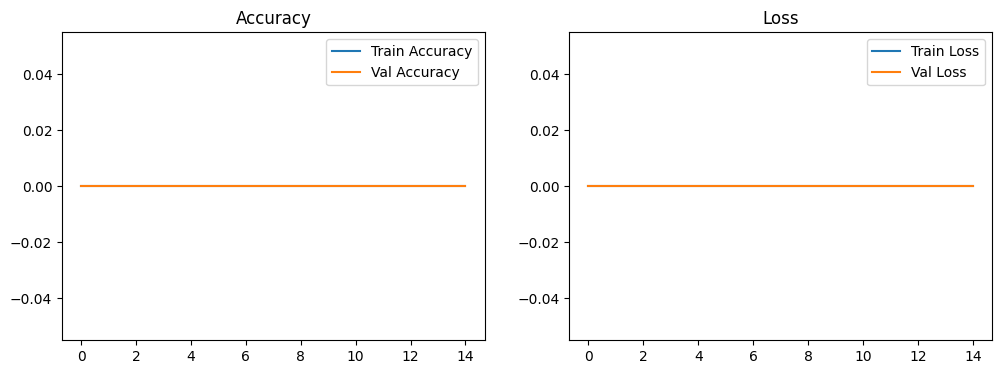

In [11]:
# 1. Train the model
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

# 2. Visualize Results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

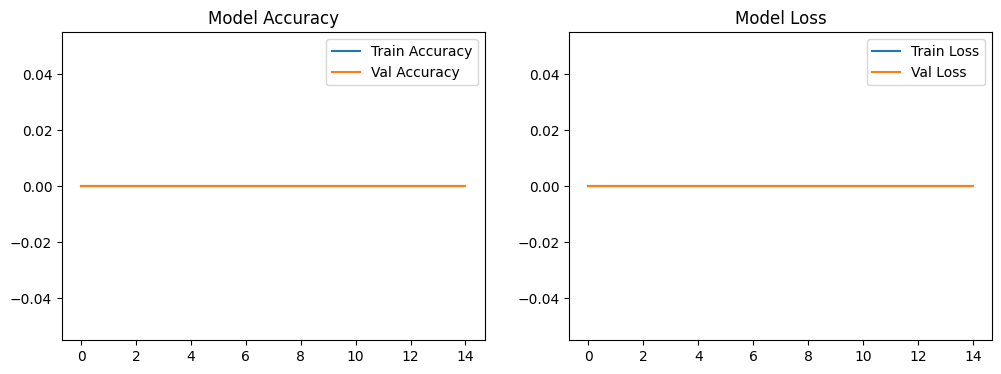

In [14]:
import matplotlib.pyplot as plt

# Save Training/Validation Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.savefig('accuracy_loss_performance.png')
plt.show()

Generating model predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


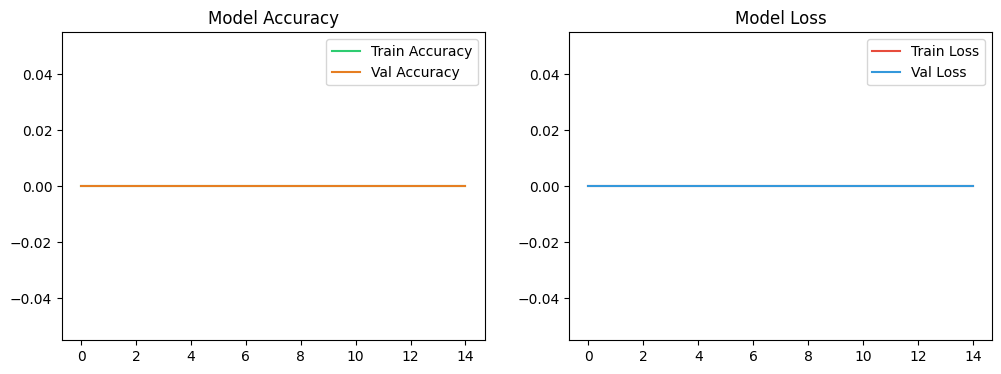

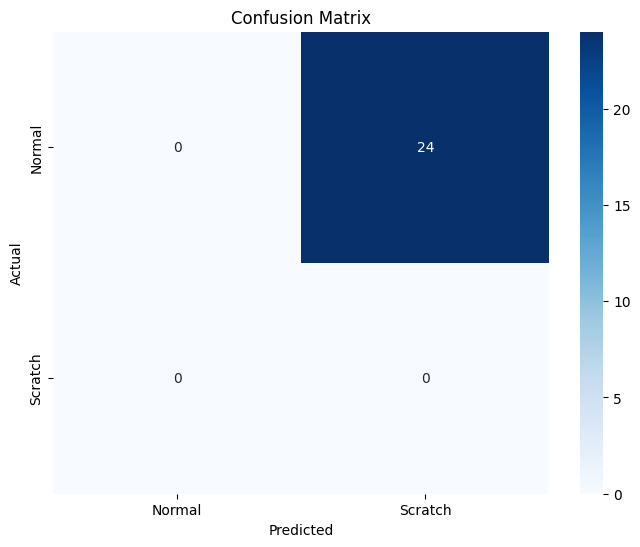

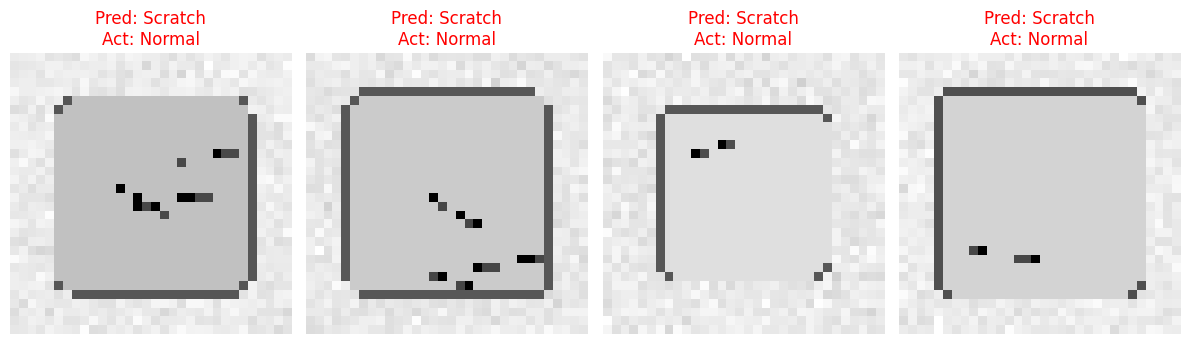


✅ ALL OUTPUTS GENERATED!
Check the folder icon on the left to download:
1. accuracy_loss_performance.png
2. confusion_matrix.png
3. predictions_output.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. GENERATE PREDICTIONS (Handles 1D and 2D arrays safely)
print("Generating model predictions...")
Y_pred = model.predict(X_test)

if Y_pred.ndim > 1 and Y_pred.shape[1] > 1:
    y_pred = np.argmax(Y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)
else:
    y_pred = (Y_pred > 0.5).astype(int).flatten()
    y_true = y_test.astype(int).flatten()

# Define your labels based on the project requirements
class_names = ['Normal', 'Scratch']

# 2. PLOT TRAINING HISTORY (Accuracy & Loss)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#e67e22')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#e74c3c')
plt.plot(history.history['val_loss'], label='Val Loss', color='#3498db')
plt.title('Model Loss')
plt.legend()
plt.savefig('accuracy_loss_performance.png')
plt.show()

# 3. PLOT CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

# 4. PLOT SAMPLE PREDICTIONS (Visual Proof)
plt.figure(figsize=(12, 4))
for i in range(min(4, len(X_test))):
    plt.subplot(1, 4, i+1)
    # Reshape back to 32x32 for display
    plt.imshow(X_test[i].reshape(32, 32), cmap='gray')
    color = 'green' if y_pred[i] == y_true[i] else 'red'
    plt.title(f"Pred: {class_names[y_pred[i]]}\nAct: {class_names[y_true[i]]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.savefig('predictions_output.png')
plt.show()

print("\n✅ ALL OUTPUTS GENERATED!")
print("Check the folder icon on the left to download:")
print("1. accuracy_loss_performance.png")
print("2. confusion_matrix.png")
print("3. predictions_output.png")